# TAM 1 vs TAM 2

Wilcoxon DE between the two macrophage clusters, canonical M1/M2 marker dotplot, TAM composition by genotype with chi-square and pairwise Fisher's exact tests.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import seaborn as sns
from scipy import stats

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=150, facecolor='white')
plt.rcParams['axes.grid'] = False
np.random.seed(1)

GENOTYPES = ['Kras-Ctrl', 'Kras-H3K36M', 'Kras-Setd2KO', 'Kras-H3K36M-Setd2KO']
TAM_CLUSTERS = ['TAM 1', 'TAM 2']
FIGDIR = '../figures'

## Load TAM cells

In [2]:
src = ad.read_h5ad('../data/processed/Gladstein Neighborhoods plus segmented tumors.h5ad', backed='r')
tam = src[src.obs['Cell Type'].isin(TAM_CLUSTERS).values].to_memory()
src.file.close()

tam.obs['Cell Type'] = tam.obs['Cell Type'].astype(str).astype('category').cat.set_categories(TAM_CLUSTERS)
tam.obs['Genotype'] = tam.obs['Genotype'].astype(str).astype('category').cat.set_categories(GENOTYPES)

print(tam)
print(tam.obs.groupby(['Genotype', 'Cell Type'], observed=True).size().unstack(fill_value=0))

AnnData object with n_obs × n_vars = 109955 × 5006
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'batch', 'Genotype', 'n_genes_by_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'leiden', 'Cell Type', 'X_centroid', 'Y_centroid', 'neigh30_kmeans30', 'Cellular Neighborhood', 'tumor', 'tumor_barcode', 'tumor_binary', 'tcell_activation_score', 'ifng_response_score', 'ifna_response_score'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Cell Type_colors', 'Cellular Neighborhood_colors', 'hvg', 'le

## DE: TAM 1 vs TAM 2 (Wilcoxon)

In [3]:
sc.tl.rank_genes_groups(tam, groupby='Cell Type', groups=TAM_CLUSTERS, reference='rest',
                        method='wilcoxon', use_raw=False, pts=True, key_added='deg_tam')

for grp in TAM_CLUSTERS:
    df = sc.get.rank_genes_groups_df(tam, group=grp, key='deg_tam')
    df.to_csv(f'{FIGDIR}/09_tam_degs_{grp.replace(" ", "")}_vs_other.csv', index=False)
    print(f'\nTop 20 up in {grp}:')
    print(df.query('pvals_adj < 0.05 and logfoldchanges > 0').head(20)
          [['names', 'logfoldchanges', 'pvals_adj', 'pct_nz_group', 'pct_nz_reference']]
          .to_string(index=False))


Top 20 up in TAM 1:
  names  logfoldchanges     pvals_adj  pct_nz_group  pct_nz_reference
 Il10ra        4.016056  0.000000e+00           1.0               1.0
   Irf5        4.040792  0.000000e+00           1.0               1.0
 Ifngr1        6.476328  0.000000e+00           1.0               1.0
  Csf1r        2.998213  0.000000e+00           1.0               1.0
   Ccr5        7.712991  0.000000e+00           1.0               1.0
   Irf8        4.465108  0.000000e+00           1.0               1.0
  Itga4        4.852977  0.000000e+00           1.0               1.0
 Slc9a9        5.191590 2.299455e-283           1.0               1.0
  Prkcd        1.584079 8.906606e-222           1.0               1.0
   Cd83        3.518877 9.173988e-216           1.0               1.0
   Ly86        4.076166 9.052451e-205           1.0               1.0
   Gm2a        1.704089 3.314805e-195           1.0               1.0
Unc93b1        2.037396 1.427642e-191           1.0               1.0

## Canonical M1 / M2 marker dotplot

Markers from Mantovani 2004, Murray 2014, Mosser & Edwards 2008, intersected with the 5006-gene panel.

In [4]:
m1 = ['Tnf', 'Nos2', 'Cxcl9', 'Cxcl10', 'Cd86', 'Stat1', 'Irf5', 'Il12a', 'Il12b']
m2 = ['Arg1', 'Mrc1', 'Chil3', 'Cd163', 'Il10', 'Tgfb1', 'Ccl17', 'Ccl24', 'Stat6', 'Pparg']
m1_present = [g for g in m1 if g in tam.var_names]
m2_present = [g for g in m2 if g in tam.var_names]

print(f'M1 in panel: {m1_present}')
print(f'M2 in panel: {m2_present}')
print(f'absent — M1: {[g for g in m1 if g not in tam.var_names]} | M2: {[g for g in m2 if g not in tam.var_names]}')

M1 in panel: ['Tnf', 'Nos2', 'Cxcl9', 'Cxcl10', 'Cd86', 'Stat1', 'Irf5', 'Il12a', 'Il12b']
M2 in panel: ['Arg1', 'Mrc1', 'Chil3', 'Cd163', 'Il10', 'Tgfb1', 'Ccl17', 'Ccl24', 'Stat6', 'Pparg']
absent — M1: [] | M2: []


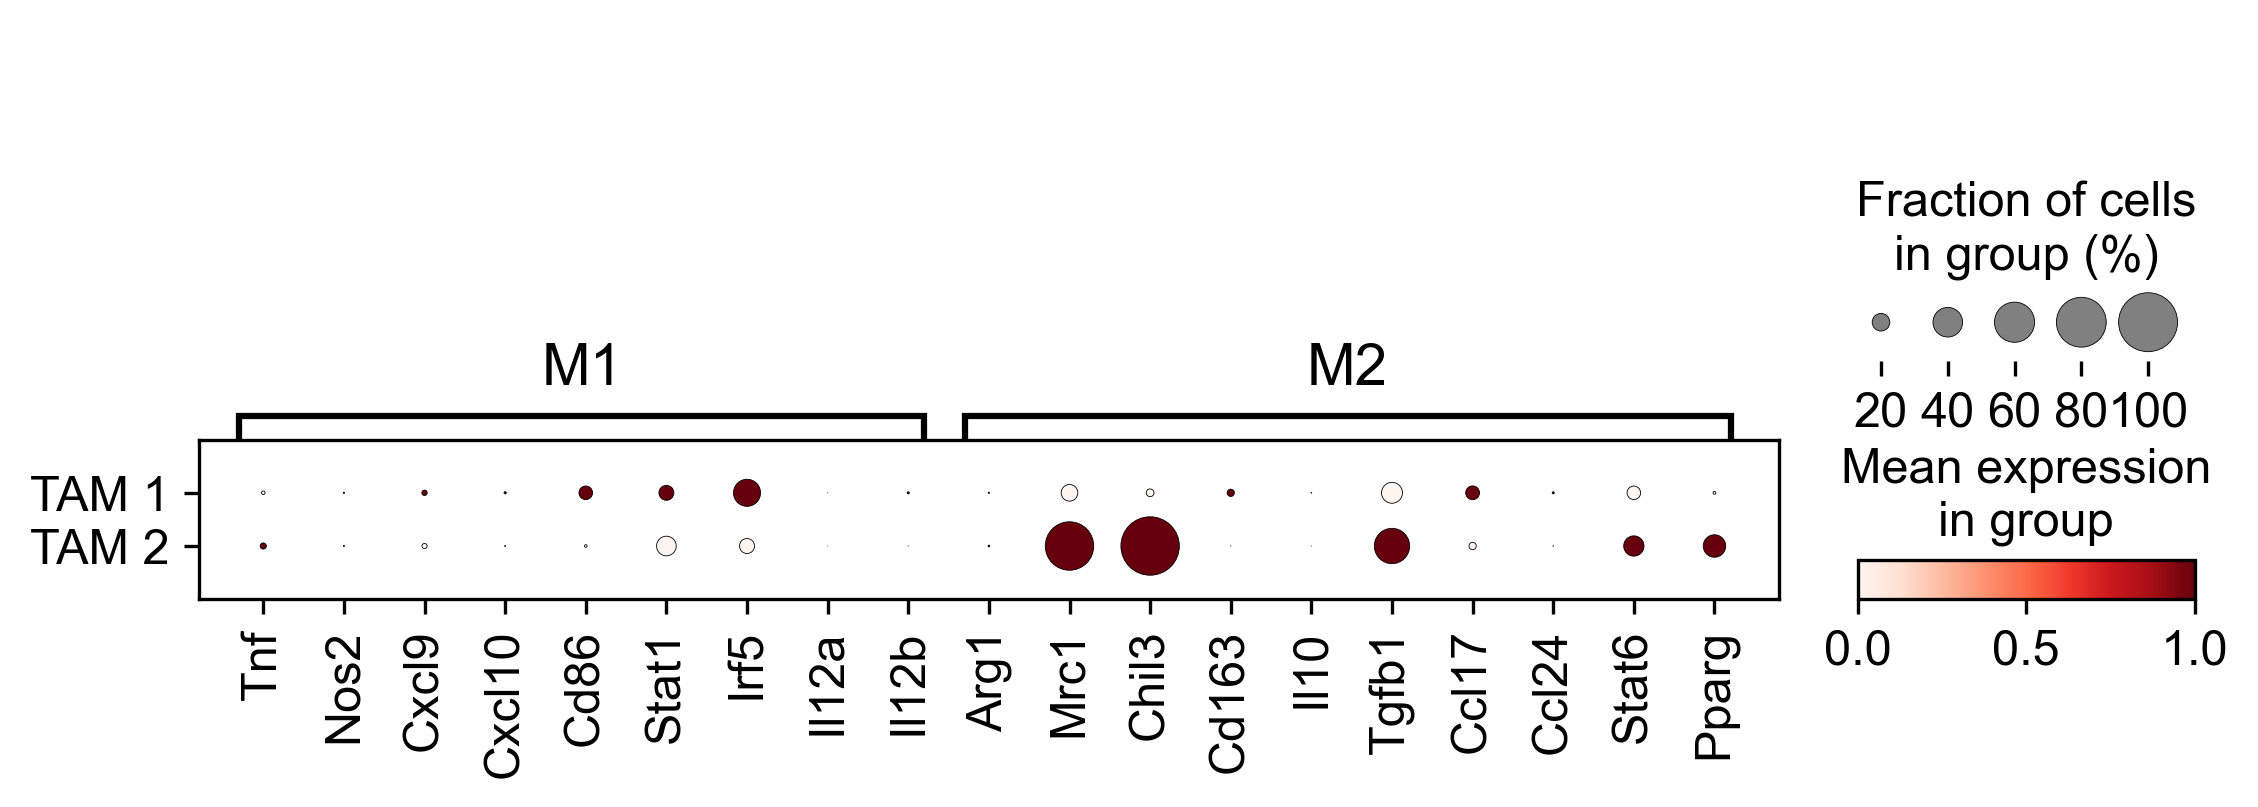

In [5]:
dp = sc.pl.dotplot(tam, {'M1': m1_present, 'M2': m2_present}, groupby='Cell Type',
                   standard_scale='var', categories_order=TAM_CLUSTERS,
                   return_fig=True, show=False)
dp.savefig(f'{FIGDIR}/09_tam_m1m2_dotplot.svg', bbox_inches='tight')
plt.show()

## TAM composition by genotype

In [6]:
geno_counts = (tam.obs.groupby(['Genotype', 'Cell Type'], observed=True).size()
               .unstack(fill_value=0).reindex(index=GENOTYPES, columns=TAM_CLUSTERS))
geno_pct = geno_counts.div(geno_counts.sum(axis=1), axis=0) * 100
out = pd.concat({'count': geno_counts, 'percent': geno_pct.round(2)}, axis=1)
out.to_csv(f'{FIGDIR}/09_tam_proportions_by_genotype.csv')
print(out)

                     count        percent       
Cell Type            TAM 1  TAM 2   TAM 1  TAM 2
Genotype                                        
Kras-Ctrl            19423  13734   58.58  41.42
Kras-H3K36M          14152   6172   69.63  30.37
Kras-Setd2KO          8275  13290   38.37  61.63
Kras-H3K36M-Setd2KO  22338  12571   63.99  36.01


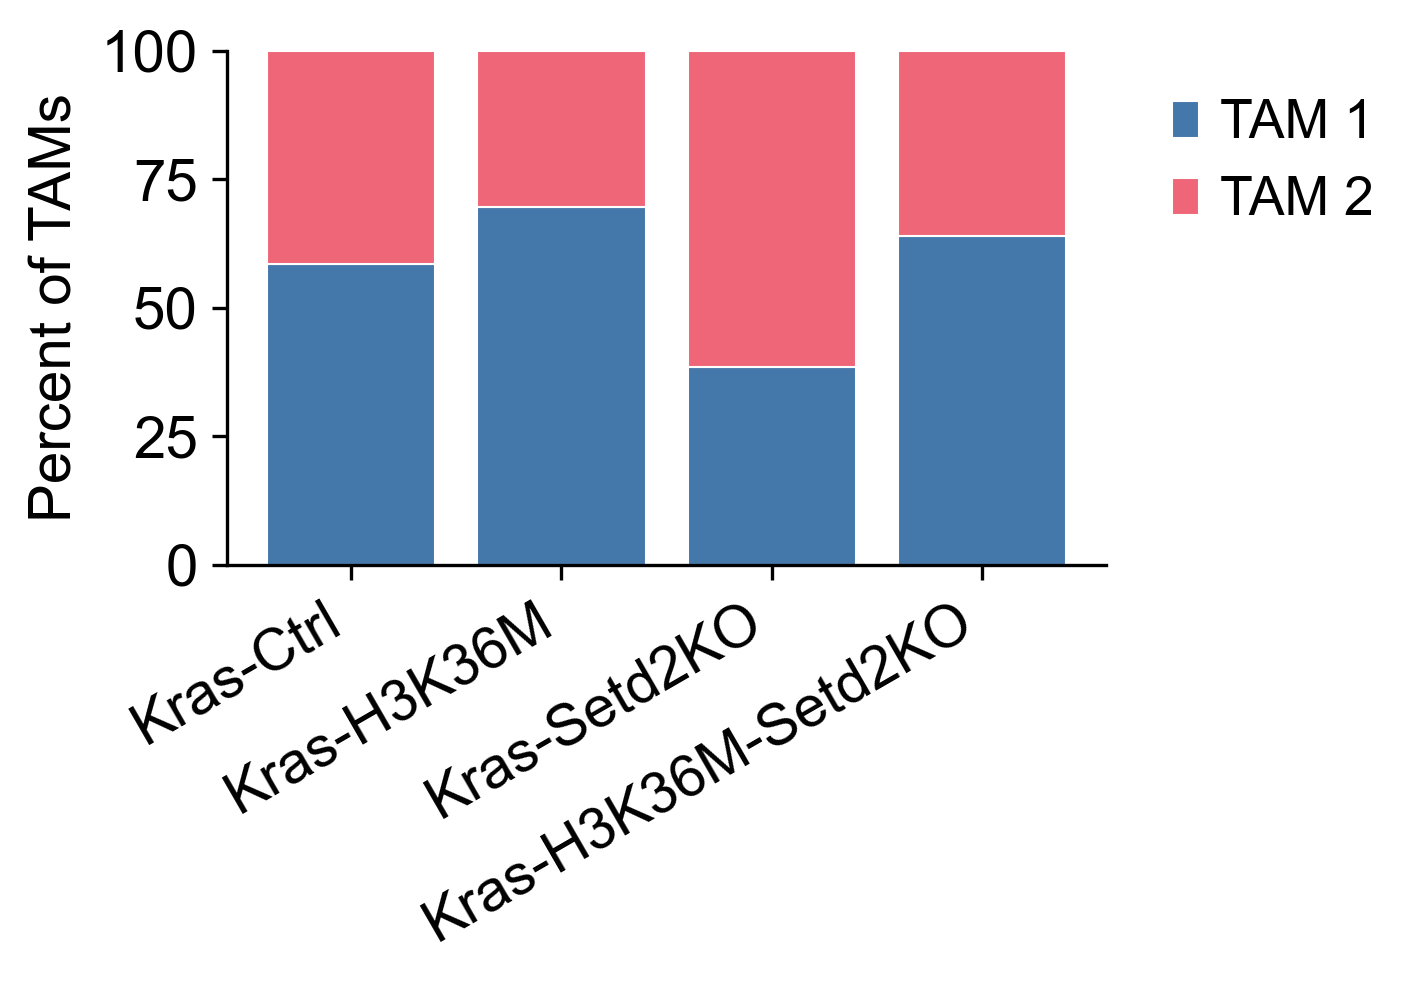

In [7]:
fig, ax = plt.subplots(figsize=(5, 3.5))
bottom = np.zeros(len(GENOTYPES))
colors = {'TAM 1': '#4477AA', 'TAM 2': '#EE6677'}
for c in TAM_CLUSTERS:
    ax.bar(GENOTYPES, geno_pct[c].values, bottom=bottom, label=c, color=colors[c], edgecolor='white', linewidth=0.5)
    bottom += geno_pct[c].values
ax.set_ylabel('Percent of TAMs'); ax.set_ylim(0, 100)
ax.set_xticklabels(GENOTYPES, rotation=30, ha='right')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/09_tam_proportions_by_genotype.svg', bbox_inches='tight')
plt.show()

## TAM 1 fraction per tumor

In [9]:
in_tumor = tam.obs[tam.obs['tumor_barcode'].astype(str) != 'NoTumor'].copy()
tumor_counts = (in_tumor.groupby(['tumor_barcode', 'Genotype', 'Cell Type'], observed=True).size()
                .unstack('Cell Type', fill_value=0).reset_index())
for c in ['TAM 1', 'TAM 2']:
    if c not in tumor_counts.columns:
        tumor_counts[c] = 0
tumor_counts['n_tam'] = tumor_counts['TAM 1'] + tumor_counts['TAM 2']
tumor_counts['pct_TAM1'] = 100 * tumor_counts['TAM 1'] / tumor_counts['n_tam']
tumor_counts = tumor_counts[tumor_counts['n_tam'] >= 10].copy()
tumor_counts.to_csv(f'{FIGDIR}/09_tam_proportions_per_tumor.csv', index=False)
print(f'tumors with >=10 TAMs: {len(tumor_counts)}')
print(tumor_counts.groupby('Genotype', observed=True).size().reindex(GENOTYPES).to_string())

tumors with >=10 TAMs: 128
Genotype
Kras-Ctrl              46
Kras-H3K36M            36
Kras-Setd2KO           19
Kras-H3K36M-Setd2KO    27


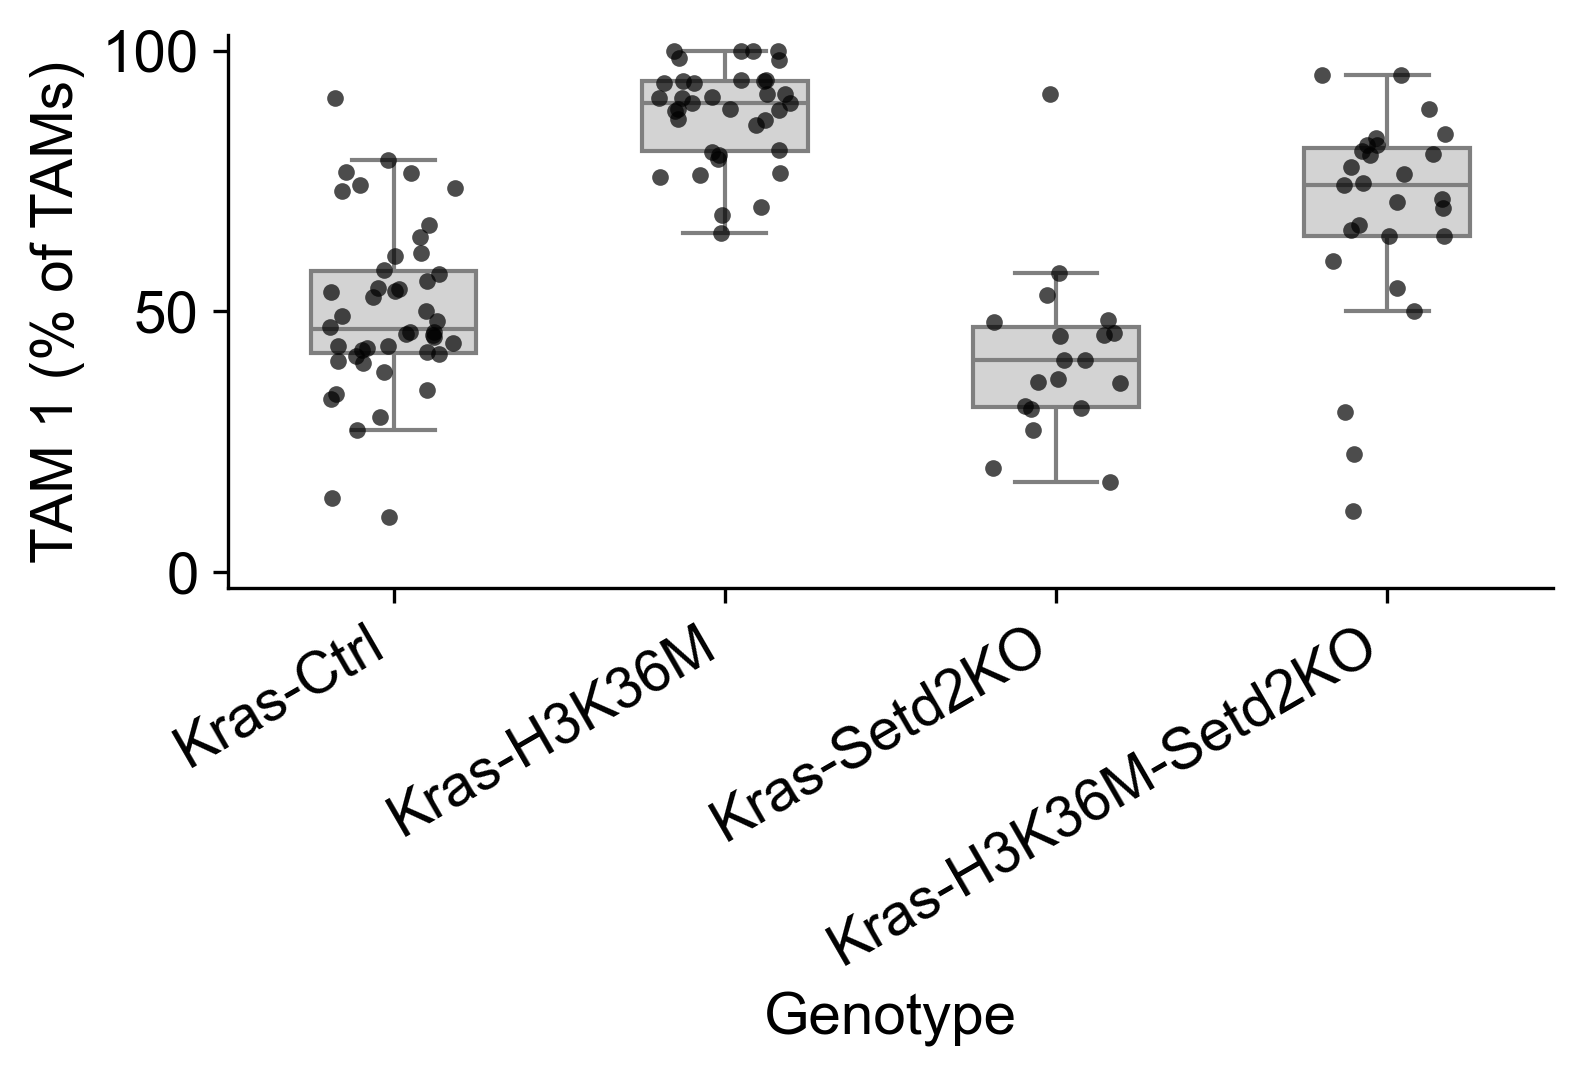

In [14]:
fig, ax = plt.subplots(figsize=(5.5, 3.8))
sns.boxplot(data=tumor_counts, x='Genotype', y='pct_TAM1',
            order=GENOTYPES, color='lightgray', width=0.5,
            showfliers=False, ax=ax)
sns.stripplot(data=tumor_counts, x='Genotype', y='pct_TAM1',
              order=GENOTYPES, color='black', size=4, alpha=0.7,
              jitter=0.2, ax=ax)
ax.set_ylabel('TAM 1 (% of TAMs)')
ax.set_ylim(-3, 103)
ax.set_xticklabels(GENOTYPES, rotation=30, ha='right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/09_tam1_per_tumor_boxplot.svg', bbox_inches='tight')
plt.show()

## Chi-square + pairwise Fisher's vs Kras-Ctrl

In [15]:
chi2, p, dof, _ = stats.chi2_contingency(geno_counts.values)
print(f'chi2 = {chi2:.2f}, dof = {dof}, p = {p:.3e}')

chi2 = 5064.30, dof = 3, p = 0.000e+00


In [16]:
ref = 'Kras-Ctrl'
mutants = [g for g in GENOTYPES if g != ref]
rows = []
for g in mutants:
    table = geno_counts.loc[[ref, g], TAM_CLUSTERS].values
    odds, p = stats.fisher_exact(table, alternative='two-sided')
    rows.append({
        'comparison': f'{g} vs {ref}',
        'TAM1_ref': table[0, 0], 'TAM2_ref': table[0, 1],
        'TAM1_test': table[1, 0], 'TAM2_test': table[1, 1],
        'odds_ratio': odds,
        'log2_odds_ratio': np.log2(odds) if odds > 0 else np.nan,
        'p_value': p,
        'p_bonferroni': min(p * len(mutants), 1.0),
    })
fisher_df = pd.DataFrame(rows)
fisher_df.to_csv(f'{FIGDIR}/09_tam_pairwise_fisher.csv', index=False)
print(fisher_df.to_string(index=False))

                      comparison  TAM1_ref  TAM2_ref  TAM1_test  TAM2_test  odds_ratio  log2_odds_ratio       p_value  p_bonferroni
        Kras-H3K36M vs Kras-Ctrl     19423     13734      14152       6172    0.616776        -0.697182 3.846379e-147 1.153914e-146
       Kras-Setd2KO vs Kras-Ctrl     19423     13734       8275      13290    2.271309         1.183524  0.000000e+00  0.000000e+00
Kras-H3K36M-Setd2KO vs Kras-Ctrl     19423     13734      22338      12571    0.795875        -0.329386  1.505863e-47  4.517589e-47
